# **1. Cluster Analysis**

# **1.1. kMeans / kModes / kPrototypes Clustering**

# Load data and select features

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [2]:
# 1) Load dataset
file_path = '/content/21_Fish_market_regression.xlsx'
df = pd.read_excel(file_path, engine='openpyxl')

In [3]:
# 2) Inspect columns and dtypes
cols = df.columns.tolist()
dtypes = df.dtypes.astype(str).to_dict()

In [65]:
# 3) Select features: use only numerical features for unsupervised learning
#    We drop the known label/identity column 'Species' if present.
num_df = df.select_dtypes(include=[np.number]).copy()
cat_cols = [c for c in df.columns if df[c].dtype == 'object']   # ['Species'] expected

In [66]:
# 4) Basic sanity checks
n_rows, n_cols = num_df.shape
na_counts = num_df.isna().sum().to_dict()

# Handle missing values: drop rows with any NA in numeric features
num_df_clean = num_df.dropna().copy()

# Keep an index mapping to retrieve corresponding original rows later
keep_idx = num_df_clean.index
df_cat = df.loc[keep_idx, cat_cols].copy() if cat_cols else pd.DataFrame(index=keep_idx)

In [67]:
# 5) Standardize features to unit scale because variables are on different scales
scaler = StandardScaler()
X = scaler.fit_transform(num_df_clean.values)

In [7]:
# 6) Compute total sum of squares (TSS) for explained variance calculation
#    TSS is the sum of squared distances to the global mean across all observations and features.
X_centered = X - X.mean(axis=0)
TSS = np.sum(X_centered ** 2)

In [8]:
# 7) Elbow method: run KMeans for k in a range and compute inertia and explained variance
k_values = list(range(1, 13))
inertias = []
explained_variances = []

# Use a reproducible random_state
for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertia = km.inertia_  # within-cluster sum of squares (WCSS)
    inertias.append(inertia)
    # Explained variance by k-means clustering: 1 - WCSS/TSS
    ev = 1 - (inertia / TSS)
    explained_variances.append(ev)

In [9]:
explained_variances

[np.float64(-4.440892098500626e-16),
 np.float64(0.6382220235474293),
 np.float64(0.7381747911582288),
 np.float64(0.8154718067864251),
 np.float64(0.8621191218435309),
 np.float64(0.8988063432491412),
 np.float64(0.9213657257132206),
 np.float64(0.9359645108627649),
 np.float64(0.9427415969183558),
 np.float64(0.9510841717762705),
 np.float64(0.9578935200731595),
 np.float64(0.9650994662843141)]

In [10]:
ev

np.float64(0.9650994662843141)

In [11]:
# 8) Heuristic to pick elbow: choose smallest k such that marginal gain (< delta_threshold)
#    in explained variance compared to previous k is below a threshold (e.g., 0.03 = 3%)
delta = np.array([0] + list(np.diff(explained_variances)))
# Thresholds to try: prioritize 3%, then 2%, else argmax 2nd derivative elbow
thresholds = [0.03, 0.02]
chosen_k = None
for thr in thresholds:
    candidates = [k for k, d in zip(k_values, delta) if (k > 1 and d < thr)]
    if candidates:
        chosen_k = candidates[0]
        break

if chosen_k is None:
    # Fall back to k with maximum curvature using second differences on inertia
    # Compute discrete second derivative of inertia (convex): find elbow as k with largest drop in slope
    inertia_arr = np.array(inertias)
    # First differences
    d1 = np.diff(inertia_arr)
    # Second differences
    d2 = np.diff(d1)
    # Map back to k index: d2 corresponds to k=3..K
    if len(d2) > 0:
        elbow_idx = np.argmax(-d2)  # most negative second diff (largest curvature)
        chosen_k = k_values[2 + elbow_idx]
    else:
        chosen_k = 3  # safe default

In [12]:
chosen_k

7

In [13]:
# 9) Fit final KMeans with chosen_k
final_kmeans = KMeans(n_clusters=chosen_k, random_state=42, n_init=10)
clusters = final_kmeans.fit_predict(X)

In [14]:
# 10) Prepare output DataFrame: original df rows kept + cluster labels
output_df = df.loc[keep_idx].copy()
output_df['cluster_kmeans'] = clusters

# 11) Save outputs
summary = {
    'n_rows_total': int(df.shape[0]),
    'n_rows_used': int(output_df.shape[0]),
    'n_numeric_features': int(num_df.shape[1]),
    'k_values': k_values,
    'inertias': inertias,
    'explained_variances': explained_variances,
    'chosen_k': int(chosen_k)
}

In [15]:
clusters

array([1, 1, 1, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
       5, 5, 5, 5, 5, 5, 6, 6, 6, 6, 6, 6, 6, 4, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 5, 6, 6, 2, 2, 2, 2, 2,
       2, 2, 2, 1, 1, 1, 4, 4, 4, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 5,
       5, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4,
       4, 4, 4, 4, 4], dtype=int32)

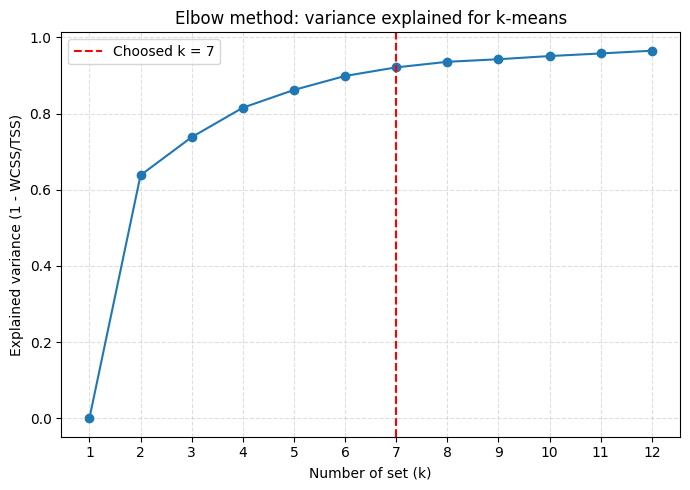

In [16]:
# 12) Plot elbow curve (Explained variance vs K) with Turkish labels
plt.figure(figsize=(7,5))
plt.plot(k_values, explained_variances, marker='o', color='#1f77b4')
plt.xticks(k_values)
plt.xlabel('Number of set (k)')
plt.ylabel('Explained variance (1 - WCSS/TSS)')
plt.title('Elbow method: variance explained for k-means')
plt.grid(True, linestyle='--', alpha=0.4)
# Highlight chosen k
plt.axvline(chosen_k, color='red', linestyle='--', label=f'Choosed k = {chosen_k}')
plt.legend()
plt.tight_layout()

plot_path = 'elbow_kmeans_explained_variance.png'
plt.savefig(plot_path, dpi=160)
plt.show()
plt.close()

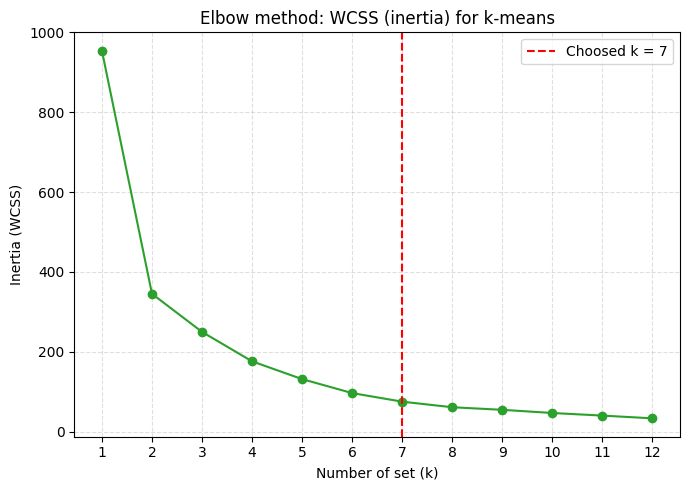

In [18]:
# Also plot inertia curve (optional) with labels
plt.figure(figsize=(7,5))
plt.plot(k_values, inertias, marker='o', color='#2ca02c')
plt.xticks(k_values)
plt.xlabel('Number of set (k)')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow method: WCSS (inertia) for k-means')
plt.grid(True, linestyle='--', alpha=0.4)
plt.axvline(chosen_k, color='red', linestyle='--', label=f'Choosed k = {chosen_k}')
plt.legend()
plt.tight_layout()

plt.show()
plt.close()

# **1.2. Hierarchical Clustering**

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import silhouette_score

In [56]:
#cancel
if 'df' not in globals():
    df = pd.read_excel('/content/21_Fish_market_regression.xlsx', engine='openpyxl')

if 'cat_cols' not in globals():
    cat_cols = [c for c in df.columns if df[c].dtype == 'object']   # ['Species'] expected
if 'num_cols' not in globals():
    num_cols = [c for c in df.columns if np.issubdtype(df[c].dtype, np.number)]

if 'df_num' not in globals():
    df_num = df[num_cols].dropna().copy()
if 'keep_idx' not in globals():
    keep_idx = df_num.index
if 'df_cat' not in globals():
    df_cat = df.loc[keep_idx, cat_cols].copy() if cat_cols else pd.DataFrame(index=keep_idx)

if 'X_num' not in globals():
    # Scale numeric features only once
    scaler = StandardScaler()
    X_num = scaler.fit_transform(df_num.values)

In [34]:
if 'choose_k_and_labels' not in globals():
    def choose_k_and_labels(Z, X, metric='euclidean', k_min=2, k_max=10):
        """Cut the dendrogram at k=2..k_max and pick k with the best silhouette."""
        best_k, best_score, best_labels = None, -1, None
        for k in range(k_min, min(k_max, X.shape[0]-1) + 1):
            labels = fcluster(Z, t=k, criterion='maxclust')
            if len(np.unique(labels)) < 2:
                continue
            try:
                score = silhouette_score(X, labels, metric=metric)
            except Exception:
                score = -1
            if score > best_score:
                best_k, best_score, best_labels = k, score, labels
        return best_k, best_score, best_labels

In [ ]:
if 'gower_distance' not in globals():
    def gower_distance(df_num_part, df_cat_part):
        """
        Compute Gower distance for mixed features.
        - Numeric features -> [0,1] by feature range; similarity = 1 - |xi - xj|
        - Categorical features -> similarity = 1 if equal else 0
        Distance = 1 - average similarity across all features.
        """
        n = df_num_part.shape[0]
        # Numeric scaled to [0,1]
        if df_num_part.shape[1] > 0:
            num_vals = df_num_part.values.astype(float)
            num_min  = np.nanmin(num_vals, axis=0)
            num_max  = np.nanmax(num_vals, axis=0)
            rng = (num_max - num_min)
            rng[rng == 0] = 1.0
            num_scaled = (num_vals - num_min) / rng
        else:
            num_scaled = np.empty((n, 0))
        # Categorical as strings
        if df_cat_part.shape[1] > 0:
            cat_vals = df_cat_part.astype(str).values
        else:
            cat_vals = np.empty((n, 0), dtype=object)

        S = np.zeros((n, n), dtype=float)
        p = df_num_part.shape[1] + df_cat_part.shape[1]
        if p == 0:
            raise ValueError("No features to compute Gower distance.")

        # Numeric contribution
        if num_scaled.shape[1] > 0:
            for j in range(num_scaled.shape[1]):
                col = num_scaled[:, j][:, None]
                S += (1.0 - np.abs(col - col.T))

        # Categorical contribution
        if cat_vals.shape[1] > 0:
            for j in range(cat_vals.shape[1]):
                col = cat_vals[:, j][:, None]
                S += (col == col.T).astype(float)

        # Average similarity and convert to distance
        S /= p
        D = 1.0 - S
        np.fill_diagonal(D, 0.0)
        return np.clip(D, 0.0, 1.0)

In [21]:
# 2) Linkage matrices for each method (re-using X_num/df_num/df_cat)

Z_single   = linkage(X, method='single',   metric='euclidean')
Z_complete = linkage(X, method='complete', metric='euclidean')
Z_ward     = linkage(X, method='ward')   # Ward assumes Euclidean

In [ ]:
#### CANCELED
# One-hot + Ward (only if we actually have categorical columns)
if cat_cols:
    try:
        enc = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    except TypeError:
        # fallback for older scikit-learn: sparse instead of sparse_output
        enc = OneHotEncoder(sparse=False, handle_unknown='ignore')
    X_cat_oh = enc.fit_transform(df_cat.values)
else:
    X_cat_oh = np.empty((X_num.shape[0], 0))
X_onehot = np.hstack([X_num, X_cat_oh])
Z_onehot_ward = linkage(X_onehot, method='ward')

In [35]:
# 3) Choose k by silhouette and get labels
num_single_k,   num_single_sil,   labels_single   = choose_k_and_labels(Z_single,   X,    metric='euclidean')
num_complete_k, num_complete_sil, labels_complete = choose_k_and_labels(Z_complete, X,    metric='euclidean')
num_ward_k,     num_ward_sil,     labels_ward     = choose_k_and_labels(Z_ward,     X,    metric='euclidean')

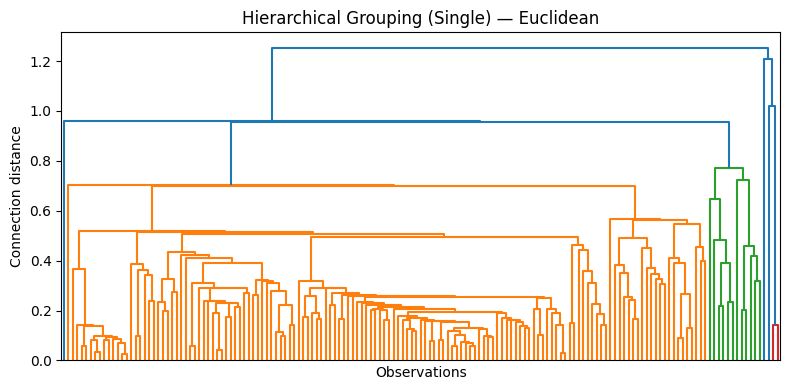

In [36]:
# 5) Dendrograms (inline)
plt.figure(figsize=(8, 4))
plt.title('Hierarchical Grouping (Single) — Euclidean')
dendrogram(Z_single, no_labels=True)
plt.xlabel('Observations'); plt.ylabel('Connection distance'); plt.tight_layout(); plt.show()

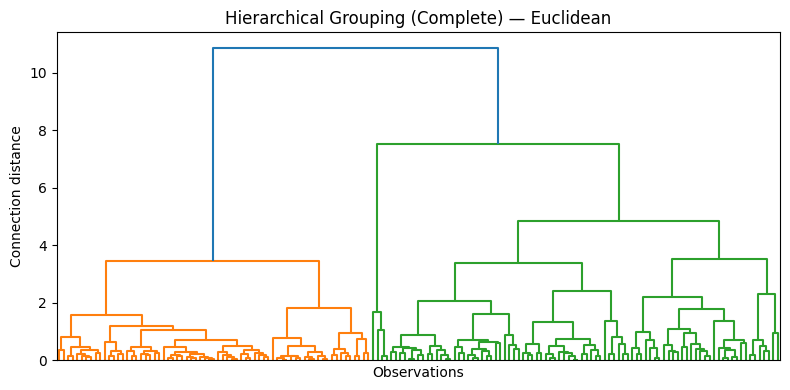

In [37]:
plt.figure(figsize=(8, 4))
plt.title('Hierarchical Grouping (Complete) — Euclidean')
dendrogram(Z_complete, no_labels=True)
plt.xlabel('Observations'); plt.ylabel('Connection distance'); plt.tight_layout(); plt.show()

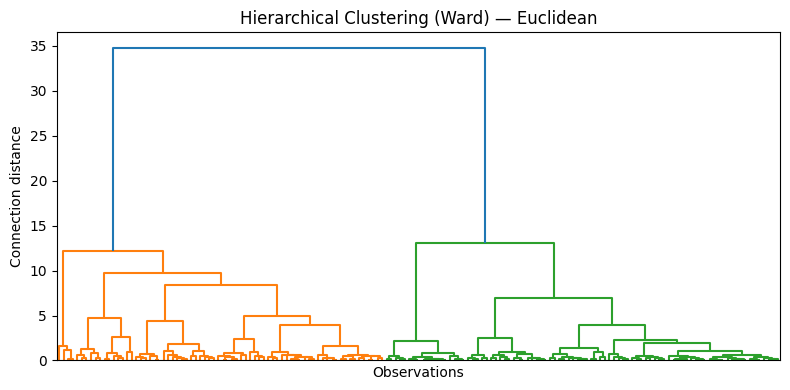

In [40]:
plt.figure(figsize=(8, 4))
plt.title('Hierarchical Clustering (Ward) — Euclidean')
dendrogram(Z_ward, no_labels=True)
plt.xlabel('Observations'); plt.ylabel('Connection distance'); plt.tight_layout(); plt.show()

In [41]:
# 6) Inline summaries
summary = {
    'numeric_single':   {'k': int(num_single_k),   'silhouette': float(num_single_sil)},
    'numeric_complete': {'k': int(num_complete_k), 'silhouette': float(num_complete_sil)},
    'numeric_ward':     {'k': int(num_ward_k),     'silhouette': float(num_ward_sil)}
}

In [42]:
print('\n[Silhouette-based recommended k per method]\n')
for m, vals in summary.items():
    print(f'{m:>18s}  k={vals["k"]:<2d}  silhouette={vals["silhouette"]:.3f}')


[Silhouette-based recommended k per method]

    numeric_single  k=2   silhouette=0.521
  numeric_complete  k=2   silhouette=0.494
      numeric_ward  k=2   silhouette=0.547


# **1.3. DBScan Clustering**

In [43]:
import numpy as np
import pandas as pd
import warnings
from sklearn.metrics import silhouette_score
from sklearn.cluster import DBSCAN
from scipy.spatial.distance import pdist, squareform

In [ ]:
# Gower distance matrix (full) for mixed data demonstrations
if 'gower_distance' not in globals():
    # Define only if missing
    def gower_distance(df_num_part, df_cat_part):
        n = df_num_part.shape[0]
        if df_num_part.shape[1] > 0:
            num_vals = df_num_part.values.astype(float)
            num_min  = np.nanmin(num_vals, axis=0)
            num_max  = np.nanmax(num_vals, axis=0)
            rng = (num_max - num_min)
            rng[rng == 0] = 1.0
            num_scaled = (num_vals - num_min) / rng
        else:
            num_scaled = np.empty((n, 0))
        if df_cat_part.shape[1] > 0:
            cat_vals = df_cat_part.astype(str).values
        else:
            cat_vals = np.empty((n, 0), dtype=object)
        S = np.zeros((n, n), dtype=float)
        p = df_num_part.shape[1] + df_cat_part.shape[1]
        if p == 0:
            raise ValueError("No features to compute Gower distance.")
        if num_scaled.shape[1] > 0:
            for j in range(num_scaled.shape[1]):
                col = num_scaled[:, j][:, None]
                S += (1.0 - np.abs(col - col.T))
        if cat_vals.shape[1] > 0:
            for j in range(cat_vals.shape[1]):
                col = cat_vals[:, j][:, None]
                S += (col == col.T).astype(float)
        S /= p
        D = 1.0 - S
        np.fill_diagonal(D, 0.0)
        return np.clip(D, 0.0, 1.0)

if 'D_gower' not in globals():
    D_gower = gower_distance(df_num.loc[keep_idx], df_cat)

In [48]:
# 1) Utility for evaluating clustering quality
def eval_labels(X_or_D, labels, metric='euclidean', precomputed=False):
    """
    Evaluate clustering labels:
    - Compute silhouette on non-noise samples (label != -1).
    - Return #clusters (excl. noise), noise_fraction, silhouette (or NaN).
    """
    labels = np.asarray(labels)
    mask = labels != -1
    n = len(labels)
    n_noise = int(np.sum(~mask))
    noise_frac = n_noise / n
    # Count clusters excluding noise
    unique = np.unique(labels[mask]) if np.any(mask) else np.array([])
    n_clusters = int(len(unique))

    sil = np.nan
    if n_clusters >= 2 and np.sum(mask) > n_clusters:
        try:
            if precomputed:
                # X_or_D is a full (n x n) distance matrix
                D = X_or_D[np.ix_(mask, mask)]
                sil = silhouette_score(D, labels[mask], metric='precomputed')
            else:
                X = X_or_D[mask]
                sil = silhouette_score(X, labels[mask], metric=metric)
        except Exception:
            sil = np.nan
    return n_clusters, noise_frac, sil

In [44]:
#cancel
# 2) DBSCAN on numeric (Euclidean) with small grid search
# -----------------------------
# Candidate eps fro quantiles of pairwise distances
dist_num = pdist(X, metric='euclidean')
q_candidates = [0.50, 0.60, 0.70, 0.80, 0.90]
eps_grid_num = [np.quantile(dist_num, q) for q in q_candidates]
min_samples_grid = [3, 5, 8, 10]

best_db_num = None
dbscan_num_summary = []


In [49]:
#cancel
for eps in eps_grid_num:
    for ms in min_samples_grid:
        labels = DBSCAN(eps=eps, min_samples=ms, metric='euclidean').fit_predict(X)
        n_clu, noise_frac, sil = eval_labels(X, labels, metric='euclidean', precomputed=False)
        dbscan_num_summary.append({'eps': eps, 'min_samples': ms,
                                   'n_clusters': n_clu, 'noise_frac': noise_frac, 'silhouette': sil})

In [50]:
#cancel
# pick best by silhouette, then by lower noise, then by higher #clusters
df_db_num = pd.DataFrame(dbscan_num_summary)
df_db_num['silhouette_rank'] = df_db_num['silhouette'].fillna(-np.inf).rank(ascending=False, method='min')
df_db_num['noise_rank'] = df_db_num['noise_frac'].rank(ascending=True, method='min')
df_db_num['clusters_rank'] = df_db_num['n_clusters'].rank(ascending=False, method='min')
df_db_num['score'] = df_db_num['silhouette_rank']*100 + df_db_num['noise_rank']*10 + df_db_num['clusters_rank']
best_db_num = df_db_num.sort_values(['score']).iloc[0].to_dict()

In [52]:
#cancel
# Refit with best params
labels_dbscan_num = DBSCAN(eps=best_db_num['eps'],
                           min_samples=int(best_db_num['min_samples']),
                           metric='euclidean').fit_predict(X)

In [ ]:
# cancel
# 3) DBSCAN on mixed data with Gower (precomputed)
# -----------------------------
# Candidate eps from quantiles of D_gower (condensed)
dist_gow = squareform(D_gower, checks=False)
eps_grid_gow = [np.quantile(dist_gow, q) for q in q_candidates]

best_db_gow = None
dbscan_gow_summary = []

for eps in eps_grid_gow:
    for ms in min_samples_grid:
        labels = DBSCAN(eps=eps, min_samples=ms, metric='precomputed').fit_predict(D_gower)
        n_clu, noise_frac, sil = eval_labels(D_gower, labels, precomputed=True)
        dbscan_gow_summary.append({'eps': eps, 'min_samples': ms,
                                   'n_clusters': n_clu, 'noise_frac': noise_frac, 'silhouette': sil})

In [ ]:
#cancel
df_db_gow = pd.DataFrame(dbscan_gow_summary)
df_db_gow['silhouette_rank'] = df_db_gow['silhouette'].fillna(-np.inf).rank(ascending=False, method='min')
df_db_gow['noise_rank'] = df_db_gow['noise_frac'].rank(ascending=True, method='min')
df_db_gow['clusters_rank'] = df_db_gow['n_clusters'].rank(ascending=False, method='min')
df_db_gow['score'] = df_db_gow['silhouette_rank']*100 + df_db_gow['noise_rank']*10 + df_db_gow['clusters_rank']
best_db_gow = df_db_gow.sort_values(['score']).iloc[0].to_dict()

labels_dbscan_gow = DBSCAN(eps=best_db_gow['eps'],
                           min_samples=int(best_db_gow['min_samples']),
                           metric='precomputed').fit_predict(D_gower)

In [54]:
# 4) HDBSCAN comparison (if library is available)
hdbscan_available = True
try:
    import hdbscan
except Exception as e:
    hdbscan_available = False
    warnings.warn("HDBSCAN is not installed in this environment; skipping HDBSCAN comparison.")

labels_hdb_num = None
best_hdb_num = None
hdbscan_num_summary = []

if hdbscan_available:
    # small grids for speed
    mcs_grid = [5, 10, 15]
    ms_grid  = [None, 5, 10]

    # Numeric (Euclidean)
    for mcs in mcs_grid:
        for ms in ms_grid:
            clusterer = hdbscan.HDBSCAN(min_cluster_size=mcs,
                                        min_samples=ms if ms is not None else None,
                                        metric='euclidean')
            lbl = clusterer.fit_predict(X)
            n_clu, noise_frac, sil = eval_labels(X, lbl, metric='euclidean', precomputed=False)
            hdbscan_num_summary.append({'min_cluster_size': mcs, 'min_samples': ms if ms else 0,
                                        'n_clusters': n_clu, 'noise_frac': noise_frac, 'silhouette': sil})
    df_hdb_num = pd.DataFrame(hdbscan_num_summary)
    df_hdb_num['silhouette_rank'] = df_hdb_num['silhouette'].fillna(-np.inf).rank(ascending=False, method='min')
    df_hdb_num['noise_rank'] = df_hdb_num['noise_frac'].rank(ascending=True, method='min')
    df_hdb_num['clusters_rank'] = df_hdb_num['n_clusters'].rank(ascending=False, method='min')
    df_hdb_num['score'] = df_hdb_num['silhouette_rank']*100 + df_hdb_num['noise_rank']*10 + df_hdb_num['clusters_rank']
    best_hdb_num = df_hdb_num.sort_values(['score']).iloc[0].to_dict()

    clusterer_num = hdbscan.HDBSCAN(min_cluster_size=int(best_hdb_num['min_cluster_size']),
                                    min_samples=int(best_hdb_num['min_samples']) if int(best_hdb_num['min_samples'])>0 else None,
                                    metric='euclidean')
    labels_hdb_num = clusterer_num.fit_predict(X)


In [62]:
# 5) Add labels into result_df (re-use if already exists)
if 'result_df' in globals():
    result_df = result_df.copy()
    base = df.loc[keep_idx].copy()
else:
    base = df.loc[keep_idx].copy()
    result_df = base.copy()
if hdbscan_available:
    result_df['hdbscan_num']   = labels_hdb_num

In [63]:
# 6) Inline reporting
if hdbscan_available:
    print("\n[HDBSCAN (Numeric, Euclidean) grid search top rows]\n")
    display(df_hdb_num.sort_values('score').head(10))
else:
    print("\n[HDBSCAN not available in this environment; skipped.]")


[HDBSCAN (Numeric, Euclidean) grid search top rows]



,min_cluster_size,min_samples,n_clusters,noise_frac,silhouette,silhouette_rank,noise_rank,clusters_rank,score
3,10,0,4,0.308176,0.615295,1.0,6.0,3.0,163.0
2,5,10,4,0.308176,0.615295,1.0,6.0,3.0,163.0
5,10,10,4,0.308176,0.615295,1.0,6.0,3.0,163.0
6,15,0,2,0.371069,0.609813,4.0,9.0,9.0,499.0
8,15,10,3,0.251572,0.560120,5.0,5.0,7.0,557.0
4,10,5,4,0.213836,0.535993,6.0,4.0,3.0,643.0
0,5,0,5,0.157233,0.532922,7.0,1.0,1.0,711.0
1,5,5,5,0.157233,0.532922,7.0,1.0,1.0,711.0
7,15,5,3,0.182390,0.526927,9.0,3.0,7.0,937.0


In [64]:
# Summaries
def summarize(X_or_D, labels, title, precomputed=False):
    n_clu, noise, sil = eval_labels(X_or_D, labels, precomputed=precomputed)
    print(f"{title:35s} | clusters={n_clu:<2d}  noise={noise:5.2%}  silhouette={sil if not np.isnan(sil) else 'NaN'}")

if hdbscan_available:
    summarize(X, labels_hdb_num,     "HDBSCAN numeric (Euclidean)", precomputed=False)

print("\n[Result head]\n")
display(result_df.head(10))

HDBSCAN numeric (Euclidean)         | clusters=4   noise=30.82%  silhouette=0.6152951513329696

[Result head]



,Species,Weight,Length1,Length2,Length3,Height,Width,dbscan_num,hdbscan_num
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200,0,-1
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056,0,-1
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961,0,-1
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555,0,1
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340,0,1
5,Bream,450.0,26.8,29.7,34.7,13.6024,4.9274,0,1
6,Bream,500.0,26.8,29.7,34.5,14.1795,5.2785,0,1
7,Bream,390.0,27.6,30.0,35.0,12.6700,4.6900,0,1
8,Bream,450.0,27.6,30.0,35.1,14.0049,4.8438,0,1
9,Bream,500.0,28.5,30.7,36.2,14.2266,4.9594,0,1


# **1.4. Clustering comparison methods**

In [ ]:
import warnings

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
    fowlkes_mallows_score
)
from sklearn.manifold import MDS
from sklearn.preprocessing import OneHotEncoder

In [ ]:

# If a one-hot embedding was used earlier and not kept, rebuild on demand
def get_X_onehot():
    if not cat_cols:
        return X_num
    try:
        enc = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    except TypeError:
        enc = OneHotEncoder(sparse=False, handle_unknown='ignore')  # fallback for older sklearn
    X_cat_oh = enc.fit_transform(df_cat.values)
    return np.hstack([X_num, X_cat_oh])

# Gower distances (full n x n); compute only if needed and missing
if 'gower_distance' not in globals():
    def gower_distance(df_num_part, df_cat_part):
        n = df_num_part.shape[0]
        if df_num_part.shape[1] > 0:
            num_vals = df_num_part.values.astype(float)
            num_min  = np.nanmin(num_vals, axis=0)
            num_max  = np.nanmax(num_vals, axis=0)
            rng = (num_max - num_min); rng[rng == 0] = 1.0
            num_scaled = (num_vals - num_min) / rng
        else:
            num_scaled = np.empty((n, 0))
        if df_cat_part.shape[1] > 0:
            cat_vals = df_cat_part.astype(str).values
        else:
            cat_vals = np.empty((n, 0), dtype=object)
        S = np.zeros((n, n), dtype=float)
        p = df_num_part.shape[1] + df_cat_part.shape[1]
        if p == 0:
            raise ValueError("No features to compute Gower distance.")
        if num_scaled.shape[1] > 0:
            for j in range(num_scaled.shape[1]):
                col = num_scaled[:, j][:, None]
                S += (1.0 - np.abs(col - col.T))
        if cat_vals.shape[1] > 0:
            for j in range(cat_vals.shape[1]):
                col = cat_vals[:, j][:, None]
                S += (col == col.T).astype(float)
        S /= p
        D = 1.0 - S
        np.fill_diagonal(D, 0.0)
        return np.clip(D, 0.0, 1.0)

if 'D_gower' not in globals():
    D_gower = gower_distance(df_num.loc[keep_idx], df_cat)

# result_df is expected from previous steps; create a minimal one if missing
if 'result_df' not in globals():
    result_df = df.loc[keep_idx].copy()

In [ ]:
# 1) Which clusterings to compare (auto-detect columns)
# ---------------------------------------
available_methods = []
candidates = [
    ('kmeans',            'cluster_kmeans',      'numeric'),          # from 1.1
    ('hc_single',         'hc_single',           'numeric'),          # from 1.2
    ('hc_complete',       'hc_complete',         'numeric'),
    ('hc_ward',           'hc_ward',             'numeric'),
    ('hc_gower_avg',      'hc_gower_avg',        'gower'),
    ('hc_gower_complete', 'hc_gower_complete',   'gower'),
    ('hc_onehot_ward',    'hc_onehot_ward',      'onehot'),           # numeric+onehot
    ('dbscan_num',        'dbscan_num',          'numeric'),          # from 1.3
    ('dbscan_gower',      'dbscan_gower',        'gower'),
    ('hdbscan_num',       'hdbscan_num',         'numeric'),
    ('hdbscan_gower',     'hdbscan_gower',       'gower'),
]

In [ ]:
for name, col, kind in candidates:
    if col in result_df.columns:
        available_methods.append((name, col, kind))

In [ ]:
# 2) Metric helpers
# ---------------------------------------
def _needs_precomputed(kind: str) -> bool:
    """Return True if this method used Gower distances and should use precomputed silhouette."""
    return kind == 'gower'

In [ ]:
def _get_feature_matrix(kind: str):
    """Return the feature matrix to use for DBI/CHI and silhouette (when not precomputed)."""
    if kind == 'numeric':
        return X_num
    elif kind == 'onehot':
        return get_X_onehot()
    elif kind == 'gower':
        # For DBI/CHI, we will embed D_gower via MDS (done later). Here return None.
        return None
    else:
        return X_num

In [ ]:
def _mds_from_distance(D, n_components=10, random_state=42):
    """Metric MDS to embed a distance matrix to an Euclidean space for DBI/CHI computation."""
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        mds = MDS(n_components=n_components, dissimilarity='precomputed',
                  random_state=random_state, n_init=1, max_iter=300, normalized_stress='auto')
        X_emb = mds.fit_transform(D)
    return X_emb

In [ ]:
def _eval_internal(X, labels, kind: str, D_precomputed=None):
    """
    Compute internal metrics:
    - silhouette (precomputed distance if kind='gower'; else Euclidean on X)
    - DBI and CHI on X (for gower -> on MDS embedding of D_precomputed)
    Handle noise (-1) by computing silhouette on non-noise subset when possible.
    """
    labels = np.asarray(labels)
    n = len(labels)
    # 2+ clusters and at least one non-noise point per cluster required
    mask_non_noise = labels != -1
    uniq = np.unique(labels[mask_non_noise]) if np.any(mask_non_noise) else np.array([])
    k_eff = len(uniq)

    # Prepare feature space for DBI/CHI
    X_for_scores = X
    if kind == 'gower':
        # Build an MDS embedding for DBI/CHI
        if D_precomputed is None:
            raise ValueError("Gower method requires D_gower for internal metrics.")
        X_for_scores = _mds_from_distance(D_precomputed)

    # SILHOUETTE
    sil = np.nan
    if k_eff >= 2 and np.sum(mask_non_noise) > k_eff:
        try:
            if _needs_precomputed(kind):
                # Use precomputed Gower distances on non-noise subset
                D_mask = D_precomputed[np.ix_(mask_non_noise, mask_non_noise)]
                sil = silhouette_score(D_mask, labels[mask_non_noise], metric='precomputed')
            else:
                sil = silhouette_score(X[mask_non_noise], labels[mask_non_noise], metric='euclidean')
        except Exception:
            sil = np.nan

    # DBI & CHI (sklearn expects a feature matrix; use X_for_scores and all points incl. noise)
    # If there is only 1 cluster (or all noise), these metrics are undefined.
    dbi = np.nan
    chi = np.nan
    if len(np.unique(labels)) >= 2 and X_for_scores is not None:
        try:
            dbi = davies_bouldin_score(X_for_scores, labels)
        except Exception:
            dbi = np.nan
        try:
            chi = calinski_harabasz_score(X_for_scores, labels)
        except Exception:
            chi = np.nan

    return sil, dbi, chi

In [ ]:
def _eval_external(y_true, labels):
    """
    External validation metrics vs. ground-truth classes (Species):
    - ARI, NMI, FMI
    Report both:
      * FULL: includes noise=-1 (if present).
      * MASKED: excludes noise (if any), to see clean comparison.
    """
    labels = np.asarray(labels)
    # Align y_true to same index (already aligned through keep_idx)
    y = np.asarray(y_true)

    # Full
    ari_full = adjusted_rand_score(y, labels)
    nmi_full = normalized_mutual_info_score(y, labels)
    fmi_full = fowlkes_mallows_score(y, labels)

    # Masked (exclude noise)
    mask = labels != -1
    if np.any(mask) and len(np.unique(labels[mask])) >= 2:
        ari_mask = adjusted_rand_score(y[mask], labels[mask])
        nmi_mask = normalized_mutual_info_score(y[mask], labels[mask])
        fmi_mask = fowlkes_mallows_score(y[mask], labels[mask])
    else:
        ari_mask = nmi_mask = fmi_mask = np.nan

    return (ari_full, nmi_full, fmi_full, ari_mask, nmi_mask, fmi_mask)

In [ ]:
# 3) Compute metrics for all available methods
# ---------------------------------------
y_true = df.loc[keep_idx, 'Species'].values

rows = []
for name, col, kind in available_methods:
    labels = result_df[col].values

    # choose feature matrix
    if kind == 'numeric':
        X = X_num
        D = None
    elif kind == 'onehot':
        X = get_X_onehot()
        D = None
    elif kind == 'gower':
        X = None            # silhouette will use precomputed; DBI/CHI will use MDS embedding
        D = D_gower
    else:
        X = X_num; D = None

    sil, dbi, chi = _eval_internal(X if X is not None else (D if kind=='gower' else X_num),
                                   labels, kind, D_precomputed=D)

    ari_full, nmi_full, fmi_full, ari_mask, nmi_mask, fmi_mask = _eval_external(y_true, labels)

    rows.append({
        'method': name,
        'clusters_total': int(len(np.unique(labels[labels!=-1]))) if np.any(labels!=-1) else 0,
        'noise_frac': float(np.mean(labels==-1)) if -1 in labels else 0.0,
        'silhouette': sil,
        'davies_bouldin': dbi,
        'calinski_harabasz': chi,
        'ARI_full': ari_full,
        'NMI_full': nmi_full,
        'FMI_full': fmi_full,
        'ARI_masked': ari_mask,
        'NMI_masked': nmi_mask,
        'FMI_masked': fmi_mask
    })

metrics_df = pd.DataFrame(rows).sort_values(
    by=['silhouette', 'calinski_harabasz', 'davies_bouldin'],
    ascending=[False, False, True]
).reset_index(drop=True)

print("\n[Comparison metrics across methods]\n")
display(metrics_df)


[Comparison metrics across methods]



,method,clusters_total,noise_frac,silhouette,davies_bouldin,calinski_harabasz,ARI_full,NMI_full,FMI_full,ARI_masked,NMI_masked,FMI_masked
0,hdbscan_num,2,0.490566,0.669937,2.345798,13.662160,0.192560,0.386712,0.430759,0.482550,0.641716,0.720432
1,hdbscan_gower,3,0.371069,0.637900,2.433789,24.551862,0.339797,0.531678,0.507774,0.475177,0.648803,0.674625
2,hc_single,2,0.000000,0.532046,0.395443,21.106443,0.011523,0.048198,0.458180,0.011523,0.048198,0.458180
3,hc_ward,4,0.000000,0.530870,0.495408,227.574068,0.224775,0.403075,0.461917,0.224775,0.403075,0.461917
4,hc_gower_avg,5,0.000000,0.490934,0.793069,166.333436,0.363389,0.569402,0.534147,0.363389,0.569402,0.534147
5,hc_onehot_ward,2,0.000000,0.482261,0.766234,199.453156,0.157543,0.308063,0.445865,0.157543,0.308063,0.445865
6,hc_complete,8,0.000000,0.450309,0.666572,289.040181,0.282035,0.497603,0.428651,0.282035,0.497603,0.428651
7,hc_gower_complete,2,0.000000,0.415195,0.842814,142.617539,0.033623,0.145076,0.364648,0.033623,0.145076,0.364648
8,dbscan_num,1,0.000000,NaN,NaN,NaN,0.000000,0.000000,0.456882,NaN,NaN,NaN
9,dbscan_gower,1,0.000000,NaN,NaN,NaN,0.000000,0.000000,0.456882,NaN,NaN,NaN


In [ ]:
# 4) Cluster–class cross-tabulation for each method
# ---------------------------------------
print("\n[Cluster–class cross-tabulations]\n")
for name, col, kind in available_methods:
    print(f"\n== {name} ==")
    labels = result_df[col].values
    ct = pd.crosstab(
        pd.Series(y_true, name='Species'),
        pd.Series(labels, name='Cluster')
    )
    display(ct)

# Optionally show head of result_df for sanity
print("\n[Result head with all labels]\n")
display(result_df.head(10))


[Cluster–class cross-tabulations]


== hc_single ==


Cluster,1,2
Species,,
Bream,0,35
Parkki,0,11
Perch,0,56
Pike,3,14
Roach,0,20
Smelt,0,14
Whitefish,0,6



== hc_complete ==


Cluster,1,2,3,4,5,6,7,8
Species,,,,,,,,
Bream,0,7,0,3,0,25,0,0
Parkki,0,0,0,7,0,0,0,4
Perch,0,17,0,27,0,2,1,9
Pike,4,0,7,0,6,0,0,0
Roach,0,0,0,15,0,1,0,4
Smelt,0,0,0,0,0,0,12,2
Whitefish,0,2,0,3,0,1,0,0



== hc_ward ==


...

Cluster,-1,0,1
Species,,,
Bream,10,25,0
Parkki,8,0,3
Perch,24,0,32
Pike,17,0,0
Roach,2,0,18
Smelt,14,0,0
Whitefish,3,0,3



== hdbscan_gower ==


Cluster,-1,0,1,2
Species,,,,
Bream,4,0,31,0
Parkki,10,0,0,1
Perch,7,16,0,33
Pike,17,0,0,0
Roach,2,0,0,18
Smelt,14,0,0,0
Whitefish,5,0,0,1



[Result head with all labels]



,Species,Weight,Length1,Length2,Length3,Height,Width,Volume,log_Weight,log_Length1,...,hc_single,hc_complete,hc_ward,hc_gower_avg,hc_gower_complete,hc_onehot_ward,dbscan_num,dbscan_gower,hdbscan_num,hdbscan_gower
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200,17678.400,5.488938,3.144152,...,2,4,4,5,2,2,0,0,-1,-1
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056,19693.440,5.669881,3.178054,...,2,4,4,5,2,2,0,0,-1,1
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961,19697.185,5.828946,3.173878,...,2,4,4,5,2,2,0,0,-1,1
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555,25550.450,5.894403,3.269569,...,2,6,2,5,2,1,0,0,0,1
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340,26129.000,6.063785,3.277145,...,2,6,2,5,2,1,0,0,0,1
5,Bream,450.0,26.8,29.7,34.7,13.6024,4.9274,27619.812,6.109248,3.288402,...,2,6,2,5,2,1,0,0,0,1
6,Bream,500.0,26.8,29.7,34.5,14.1795,5.2785,27460.620,6.214608,3.288402,...,2,6,2,5,2,1,0,0,0,1
7,Bream,390.0,27.6,30.0,35.0,12.6700,4.6900,28980.000,5.966147,3.317816,...,2,6,2,5,2,1,0,0,0,1
8,Bream,450.0,27.6,30.0,35.1,14.0049,4.8438,29062.800,6.109248,3.317816,...,2,6,2,5,2,1,0,0,0,1
9,Bream,500.0,28.5,30.7,36.2,14.2266,4.9594,31673.190,6.214608,3.349904,...,2,6,2,5,2,1,0,0,0,1


# **2. Dimensionality reduction**

# **2.1. PCA/MCA/FAMD**

In [ ]:
import plotly.express as px

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA

In [ ]:
# Standardized numeric matrix (if not already present)
if 'X_num' not in globals():
    scaler = StandardScaler()
    X_num = scaler.fit_transform(df_num.values)

# Target for coloring
y_color = df.loc[keep_idx, 'Species'] if 'Species' in df.columns else pd.Series(index=keep_idx, dtype=str)

In [ ]:
# 1) PCA (numeric features only)
# -------------------------------------------------------
# Full PCA to get explained variance across all components
pca_full = PCA(random_state=42)
X_pca_full = pca_full.fit_transform(X_num)
pca_expl_var = pca_full.explained_variance_ratio_
pca_cum = np.cumsum(pca_expl_var)

In [ ]:
# 2D components
pca2 = PCA(n_components=2, random_state=42)
X_pca2 = pca2.fit_transform(X_num)
pca2_df = pd.DataFrame(X_pca2, index=keep_idx, columns=['PC1', 'PC2'])
pca2_df['Species'] = y_color.values

In [ ]:
# 3D components
pca3 = PCA(n_components=3, random_state=42)
X_pca3 = pca3.fit_transform(X_num)
pca3_df = pd.DataFrame(X_pca3, index=keep_idx, columns=['PC1', 'PC2', 'PC3'])
pca3_df['Species'] = y_color.values

In [ ]:
# Plotly – PCA 2D
fig_pca2 = px.scatter(
    pca2_df, x='PC1', y='PC2', color='Species',
    title='PCA (2B) — Color: Species',
    labels={'PC1': f'PC1 (%{pca2.explained_variance_ratio_[0]*100:.1f})',
            'PC2': f'PC2 (%{pca2.explained_variance_ratio_[1]*100:.1f})'}
)
fig_pca2.show()

In [ ]:
# Plotly – PCA 3D
fig_pca3 = px.scatter_3d(
    pca3_df, x='PC1', y='PC2', z='PC3', color='Species',
    title='PCA (3B) — Color: Species'
)
fig_pca3.show()

In [ ]:
# Plotly – PCA cumulative explained variance
pca_cum_df = pd.DataFrame({
    'Number of Components': np.arange(1, len(pca_cum)+1),
    'Cumulative Explained Variance': pca_cum
})

In [ ]:
fig_pca_cum = px.line(
    pca_cum_df, x='Number of Components', y='Cumulative Explained Variance',
    title='PCA — Cumulative Explained Variance',
    markers=True
)
fig_pca_cum.show()

In [ ]:
print("[PCA] First 3 components explained variance ratios:",
      np.round(pca_expl_var[:3], 4), " | cumulative (3):",
      round(pca_cum[2], 4))

[PCA] First 3 components explained variance ratios: [0.8749 0.0797 0.0268]  | cumulative (3): 0.9814


In [ ]:
# 2) MCA (categorical; here only 'Species') — try prince first, else CA on one-hot
# -------------------------------------------------------
def run_mca_with_fallback(df_cat_only, y_series, n_components=3):
    """
    Try MCA via 'prince' if available; otherwise fallback to CA on indicator matrix:
    - Build complete disjunctive (one-hot) table Z (n x m)
    - Perform correspondence analysis SVD on P = Z/n
    - Return row principal coordinates (scores) and eigenvalue-based explained variance.
    """
    # If prince is available
    try:
        import prince  # type: ignore
        mca = prince.MCA(n_components=n_components, random_state=42)
        Z = df_cat_only.astype('category')
        rows = mca.fit_transform(Z)
        # prince provides eigenvalues_ and explained_inertia_
        ev = np.array(mca.eigenvalues_) if hasattr(mca, 'eigenvalues_') else None
        evr = np.array(mca.explained_inertia_) if hasattr(mca, 'explained_inertia_') else None
        coords = rows.values
        return coords, evr, ev
    except Exception:
        pass

    # ---- Fallback MCA via CA on one-hot (simple implementation) ----
    # One-hot
    try:
        enc = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    except TypeError:
        enc = OneHotEncoder(sparse=False, handle_unknown='ignore')
    Z = enc.fit_transform(df_cat_only.values)        # (n x m)
    n = Z.shape[0]
    P = Z / n                                       # relative frequencies
    r = P.sum(axis=1, keepdims=True)               # row masses
    c = P.sum(axis=0, keepdims=True)               # column masses
    # Avoid zeros
    r[r == 0] = 1e-12
    c[c == 0] = 1e-12
    # Standardized residuals
    R_inv_sqrt = (1.0 / np.sqrt(r))
    C_inv_sqrt = (1.0 / np.sqrt(c))
    S = R_inv_sqrt * (P - r @ c) * C_inv_sqrt
    # SVD
    U, s, VT = np.linalg.svd(S, full_matrices=False)
    eig = s**2
    total_inertia = eig.sum() if eig.sum() > 0 else 1.0
    explained = eig / total_inertia
    # Row principal coords (F) = D_r^{-1/2} U Σ
    F = (R_inv_sqrt.squeeze()[:, None]) * (U * s)
    return F[:, :n_components], explained, eig

In [ ]:
# Prepare categorical-only frame for MCA
df_mca_cat = df.loc[keep_idx, ['Species']].copy() if 'Species' in df.columns else pd.DataFrame(index=keep_idx)
mca_coords, mca_evr, mca_eig = run_mca_with_fallback(df_mca_cat, y_color, n_components=3)

In [ ]:
# MCA 2D
mca2_df = pd.DataFrame(mca_coords[:, :2], index=keep_idx, columns=['MC1', 'MC2'])
mca2_df['Species'] = y_color.values
fig_mca2 = px.scatter(
    mca2_df, x='MC1', y='MC2', color='Species',
    title='MCA (2B) — Color: Species'
)
fig_mca2.show()

In [ ]:
# MCA 3D
mca3_df = pd.DataFrame(mca_coords[:, :3], index=keep_idx, columns=['MC1', 'MC2', 'MC3'])
mca3_df['Species'] = y_color.values
fig_mca3 = px.scatter_3d(
    mca3_df, x='MC1', y='MC2', z='MC3', color='Species',
    title='MCA (3B) — Color: Species'
)
fig_mca3.show()

In [ ]:
# MCA cumulative explained variance
if mca_evr is not None:
    mca_cum = np.cumsum(mca_evr)
    mca_cum_df = pd.DataFrame({
        'Number of Components': np.arange(1, len(mca_cum)+1),
        'Cumulative Explained Variance': mca_cum
    })
    fig_mca_cum = px.line(
        mca_cum_df, x='Number of Components', y='Cumulative Explained Variance',
        title='MCA — Cumulative Explained Variance',
        markers=True
    )
    fig_mca_cum.show()
    print("[MCA] First 3 components cumulative explained:",
          round(mca_cum[min(2, len(mca_cum)-1)], 4))
else:
    print("[MCA] Explained variance could not be computed (fallback produced no ratios).")

[MCA] First 3 components cumulative explained: 0.5


In [ ]:
# 3) FAMD (mixed data) — try prince; else PCA on [X_num | one-hot(cat)/sqrt(K)]
# -------------------------------------------------------
def run_famd_with_fallback(df_num_part, df_cat_part, n_components=3):
    """
    Try FAMD via 'prince' if available; else approximate FAMD:
    - Standardize numeric part (X_num already standardized).
    - One-hot encode each categorical variable with K levels and scale each block by 1/sqrt(K).
    - Concatenate [X_num | scaled one-hot] and run PCA.
    Return (coords_full, explained_variance_ratio_full, fitted_PCA_model).
    """
    # prince if available
    try:
        import prince  # type: ignore
        famd = prince.FAMD(n_components=n_components, random_state=42)
        Z = pd.concat([df_num_part.reset_index(drop=True),
                       df_cat_part.reset_index(drop=True)], axis=1)
        rows = famd.fit_transform(Z)
        # prince: explained_inertia_ is available
        evr = np.array(famd.explained_inertia_) if hasattr(famd, 'explained_inertia_') else None
        coords = rows.values
        return coords, evr, None
    except Exception:
        pass

In [ ]:

# 3) FAMD (mixed data) — try prince; else PCA on [X_num | one-hot(cat)/sqrt(K)]
# -------------------------------------------------------
def run_famd_with_fallback(df_num_part, df_cat_part, n_components=3):
    """
    Try FAMD via 'prince' if available; else approximate FAMD:
    - Standardize numeric part (X_num already standardized).
    - One-hot encode each categorical variable with K levels and scale each block by 1/sqrt(K).
    - Concatenate [X_num | scaled one-hot] and run PCA.
    Return (coords_full, explained_variance_ratio_full, fitted_PCA_model).
    """
    # prince if available
    try:
        import prince  # type: ignore
        famd = prince.FAMD(n_components=n_components, random_state=42)
        Z = pd.concat([df_num_part.reset_index(drop=True),
                       df_cat_part.reset_index(drop=True)], axis=1)
        rows = famd.fit_transform(Z)
        # prince: explained_inertia_ is available
        evr = np.array(famd.explained_inertia_) if hasattr(famd, 'explained_inertia_') else None
        coords = rows.values
        return coords, evr, None
    except Exception:
        pass

    # ---- Fallback FAMD via PCA on weighted mixed matrix ----
    # (Assumes X_num already standardized)
    Xn = X_num  # standardized numeric already available
    # One-hot encode cateogricals
    if df_cat_part.shape[1] > 0:
        try:
            enc = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
        except TypeError:
            enc = OneHotEncoder(sparse=False, handle_unknown='ignore')
        X_cat_oh = enc.fit_transform(df_cat_part.values)
        # Compute 1/sqrt(K_j) per variable block; here, with a single 'Species', K = n_species
        # If multiple categoricals, we would scale per-block. With one variable it's a single K.
        if hasattr(enc, 'categories_'):
            blocks = [len(cats) for cats in enc.categories_]
        else:
            # Fallback: assume single block size = number of columns in one-hot
            blocks = [X_cat_oh.shape[1]]
        # Build scaling vector
        scales = []
        col = 0
        for K in blocks:
            scales.extend([1.0/np.sqrt(K)] * K)
            col += K
        scales = np.array(scales)
        X_cat_scaled = X_cat_oh * scales
    else:
        X_cat_scaled = np.empty((Xn.shape[0], 0))

    X_mix = np.hstack([Xn, X_cat_scaled])
    pca_mix = PCA(random_state=42)
    mix_full = pca_mix.fit_transform(X_mix)
    evr_full = pca_mix.explained_variance_ratio_
    return mix_full, evr_full, pca_mix

famd_coords_full, famd_evr_full, famd_pca_model = run_famd_with_fallback(
    df_num.loc[keep_idx], df_cat, n_components=3
)

# 2D / 3D scores from FAMD space
famd2_df = pd.DataFrame(famd_coords_full[:, :2], index=keep_idx, columns=['F1', 'F2'])
famd2_df['Species'] = y_color.values
fig_famd2 = px.scatter(
    famd2_df, x='F1', y='F2', color='Species',
    title='FAMD (2B) — Color: Species'
)
fig_famd2.show()

famd3_df = pd.DataFrame(famd_coords_full[:, :3], index=keep_idx, columns=['F1', 'F2', 'F3'])
famd3_df['Species'] = y_color.values
fig_famd3 = px.scatter_3d(
    famd3_df, x='F1', y='F2', z='F3', color='Species',
    title='FAMD (3B) — Color: Species'
)
fig_famd3.show()

# Cumulative explained variance (FAMD)
if famd_evr_full is not None:
    famd_cum = np.cumsum(famd_evr_full)
    famd_cum_df = pd.DataFrame({
        'Number of Components': np.arange(1, len(famd_cum)+1),
        'Cumulative Explained Variance': famd_cum
    })
    fig_famd_cum = px.line(
        famd_cum_df, x='Number of Components', y='Cumulative Explained Variance',
        title='FAMD — Cumulative Explained Variance',
        markers=True
    )
    fig_famd_cum.show()
    print("[FAMD] First 3 components cumulative explained:",
          round(famd_cum[min(2, len(famd_cum)-1)], 4))
else:
    print("[FAMD] Explained variance ratios not available.")

[FAMD] First 3 components cumulative explained: 0.9763


# **2.2. tSNE**

In [ ]:
import plotly.express as px
from sklearn.manifold import TSNE

In [ ]:
# Target for coloring
if 'y_color' not in globals():
    y_color = df.loc[keep_idx, 'Species'] if 'Species' in df.columns else pd.Series(index=keep_idx, dtype=str)

# Gower distance matrix for mixed data if missing
if 'gower_distance' not in globals():
    def gower_distance(df_num_part, df_cat_part):
        n = df_num_part.shape[0]
        if df_num_part.shape[1] > 0:
            num_vals = df_num_part.values.astype(float)
            num_min  = np.nanmin(num_vals, axis=0)
            num_max  = np.nanmax(num_vals, axis=0)
            rng = (num_max - num_min); rng[rng == 0] = 1.0
            num_scaled = (num_vals - num_min) / rng
        else:
            num_scaled = np.empty((n, 0))
        if df_cat_part.shape[1] > 0:
            cat_vals = df_cat_part.astype(str).values
        else:
            cat_vals = np.empty((n, 0), dtype=object)
        S = np.zeros((n, n), dtype=float)
        p = df_num_part.shape[1] + df_cat_part.shape[1]
        if p == 0: raise ValueError("No features to compute Gower distance.")
        if num_scaled.shape[1] > 0:
            for j in range(num_scaled.shape[1]):
                col = num_scaled[:, j][:, None]
                S += (1.0 - np.abs(col - col.T))
        if cat_vals.shape[1] > 0:
            for j in range(cat_vals.shape[1]):
                col = cat_vals[:, j][:, None]
                S += (col == col.T).astype(float)
        S /= p
        D = 1.0 - S
        np.fill_diagonal(D, 0.0)
        return np.clip(D, 0.0, 1.0)

if 'D_gower' not in globals():
    D_gower = gower_distance(df_num.loc[keep_idx], df_cat)

n_samples = len(keep_idx)

In [ ]:
# 1) Small helper to run TSNE and plot with Plotly
# -------------------------------------------
def tsne_and_plot(X_or_D, labels, title, n_components=2, metric='euclidean', random_state=42,
                  perplexity=30, n_iter=1000, learning_rate='auto', precomputed=False):
    """
    Run t-SNE and plot with Plotly Express (2D or 3D).
    - X_or_D: feature matrix (numeric) or full distance matrix if precomputed=True
    - labels: class labels for coloring
    - metric: 'euclidean' for numeric, 'precomputed' for Gower
    """
    assert perplexity < (n_samples - 1) / 3, "Perplexity too large for sample size."
    tsne = TSNE(
        n_components=n_components,
        perplexity=perplexity,
        n_iter=n_iter,
        metric=('precomputed' if precomputed else metric),
        learning_rate=learning_rate,
        init='pca',
        random_state=random_state,
        verbose=0
    )
    Y = tsne.fit_transform(X_or_D)
    cols = [f"tSNE{i+1}" for i in range(n_components)]
    df_vis = pd.DataFrame(Y, index=keep_idx, columns=cols)
    df_vis['Species'] = labels.values

    subtitle = f"(perplexity={perplexity}, n_iter={n_iter}, metric={'Gower/precomputed' if precomputed else metric})"
    if n_components == 2:
        fig = px.scatter(
            df_vis, x='tSNE1', y='tSNE2', color='Species',
            title=f"t-SNE 2D — {title} {subtitle}"
        )
        fig.show()
    else:
        fig = px.scatter_3d(
            df_vis, x='tSNE1', y='tSNE2', z='tSNE3', color='Species',
            title=f"t-SNE 3D — {title} {subtitle}"
        )
        fig.show()

In [ ]:
# 2) Parameter grids (kept small to be fast & illustrative)
# -------------------------------------------
perplexities_2d = [5, 30, 50]     # all valid for n≈159
iters_2d       = [750, 1000]

perplexities_3d = [30]            # keep 3D lighter
iters_3d       = [750]

In [ ]:
# 3) Run t-SNE (NUMERIC / Euclidean) — 2D & 3D
# -------------------------------------------
print("\n[ t‑SNE on numeric features (Euclidean) ]\n")
for p in perplexities_2d:
    for it in iters_2d:
        tsne_and_plot(
            X_or_D=X_num, labels=y_color, title="Numeric (Euclidean)",
            n_components=2, metric='euclidean', perplexity=p, n_iter=it
        )

for p in perplexities_3d:
    for it in iters_3d:
        tsne_and_plot(
            X_or_D=X_num, labels=y_color, title="Numeric (Euclidean)",
            n_components=3, metric='euclidean', perplexity=p, n_iter=it
        )


[ t‑SNE on numeric features (Euclidean) ]



/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning:

'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.



/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning:

'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.



/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning:

'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.



/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning:

'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.



/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning:

'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.



/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning:

'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.



/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning:

'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.



In [ ]:
# keep_idx, y_color, D_gower already exist in the notebook environment.
n_samples = len(keep_idx)

def tsne_and_plot(X_or_D, labels, title, n_components=2, metric='euclidean', random_state=42,
                  perplexity=30, n_iter=1000, learning_rate='auto', precomputed=False):
    """
    Run t-SNE and plot with Plotly Express (2D or 3D).
    NOTE:
      - As of sklearn>=1.5, 'n_iter' was renamed to 'max_iter'. We ONLY set 'max_iter' to avoid conflicts.
      - With precomputed distances, init='pca' is invalid; we force init='random'.
    """
    assert perplexity < (n_samples - 1) / 3, "Perplexity too large for sample size."

    tsne_params = dict(
        n_components=n_components,
        perplexity=perplexity,
        learning_rate=learning_rate,
        random_state=random_state,
        verbose=0,
        # use only max_iter to be future-proof
        max_iter=n_iter
    )

    if precomputed:
        tsne_params['metric'] = 'precomputed'
        tsne_params['init'] = 'random'   # critical for precomputed distances
    else:
        tsne_params['metric'] = metric
        tsne_params['init'] = 'pca'

    tsne = TSNE(**tsne_params)
    Y = tsne.fit_transform(X_or_D)

    cols = [f"tSNE{i+1}" for i in range(n_components)]
    df_vis = pd.DataFrame(Y, index=keep_idx, columns=cols)
    df_vis['Species'] = labels.values

    subtitle = f"(perplexity={perplexity}, max_iter={n_iter}, metric={'Gower/precomputed' if precomputed else metric})"
    if n_components == 2:
        fig = px.scatter(df_vis, x='tSNE1', y='tSNE2', color='Species',
                         title=f"t-SNE 2D — {title} {subtitle}")
        fig.show()
    else:
        fig = px.scatter_3d(df_vis, x='tSNE1', y='tSNE2', z='tSNE3', color='Species',
                            title=f"t-SNE 3D — {title} {subtitle}")
        fig.show()

print("\n[Fixed v2] t‑SNE on mixed-type features (Gower distance, precomputed)\n")

# Re-run only the Gower t-SNEs
perplexities_2d = [5, 30, 50]
iters_2d       = [750, 1000]

perplexities_3d = [30]
iters_3d       = [750]

# 2D Gower t-SNE
for p in perplexities_2d:
    for it in iters_2d:
        tsne_and_plot(
            X_or_D=D_gower, labels=y_color, title="Mixed (Gower distance)",
            n_components=2, precomputed=True, perplexity=p, n_iter=it
        )

# 3D Gower t-SNE
for p in perplexities_3d:
    for it in iters_3d:
        tsne_and_plot(
            X_or_D=D_gower, labels=y_color, title="Mixed (Gower distance)",
            n_components=3, precomputed=True, perplexity=p, n_iter=it
        )

print("\n[INFO] Gower-based t‑SNE re-runs completed with only max_iter and init='random'")


[Fixed v2] t‑SNE on mixed-type features (Gower distance, precomputed)




[INFO] Gower-based t‑SNE re-runs completed with only max_iter and init='random'


# **3. Integration of dimensionality reduction into clustering**

## **3.1. Clustering on reduced feature space**

In [ ]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import pdist
from sklearn.metrics import silhouette_score

In [ ]:
# 1) Pick PCA dimensionality s.t. cumulative explained variance >= 85%
# -------------------------------------------------------
# Reuse full PCA if already present; else fit it now.
if 'pca_full' in globals():
    pca_expl_var = pca_full.explained_variance_ratio_
else:
    pca_full = PCA(random_state=42)
    _ = pca_full.fit_transform(X_num)
    pca_expl_var = pca_full.explained_variance_ratio_

pca_cum = np.cumsum(pca_expl_var)
pca_k = int(np.searchsorted(pca_cum, 0.85) + 1)
pca_k = max(2, pca_k)  # at least 2 components for meaningful plots
print(f"[PCA] Selected number of components (>=85% variance): k = {pca_k}  | cumulative = {pca_cum[pca_k-1]:.3f}")

# Build reduced PCA feature matrix
pca_red = PCA(n_components=pca_k, random_state=42)
X_pca_red = pca_red.fit_transform(X_num)

[PCA] Selected number of components (>=85% variance): k = 2  | cumulative = 0.955


In [ ]:
# 2) Helper utilities
# -------------------------------------------------------
if 'eval_labels' not in globals():
    def eval_labels(X, labels, metric='euclidean', precomputed=False):
        """Silhouette on non-noise samples; also return number of clusters and noise fraction."""
        labels = np.asarray(labels)
        mask = labels != -1
        n = len(labels)
        n_noise = int((~mask).sum())
        noise_frac = n_noise / n
        uniq = np.unique(labels[mask]) if np.any(mask) else np.array([])
        n_clusters = int(len(uniq))
        sil = np.nan
        if n_clusters >= 2 and mask.sum() > n_clusters:
            try:
                if precomputed:
                    D = X[np.ix_(mask, mask)]
                    sil = silhouette_score(D, labels[mask], metric='precomputed')
                else:
                    sil = silhouette_score(X[mask], labels[mask], metric=metric)
            except Exception:
                sil = np.nan
        return n_clusters, noise_frac, sil

if 'best_label_alignment' not in globals():
    def best_label_alignment(labels_ref, labels_new):
        """
        Align labels_new to labels_ref via Hungarian assignment on the confusion matrix
        (ignoring noise label -1 if present). Returns:
          matched_count, matched_fraction, mapping_dict
        """
        a = np.asarray(labels_ref)
        b = np.asarray(labels_new)

        # Exclude noise points for matching if present in any
        mask = (a != -1) & (b != -1)
        if not np.any(mask):
            # No comparable points; treat as zero match
            return 0, 0.0, {}

        a_u = np.unique(a[mask])
        b_u = np.unique(b[mask])

        # Build contingency table (|A| x |B|)
        A = pd.Series(a[mask], dtype=int)
        B = pd.Series(b[mask], dtype=int)
        ct = pd.crosstab(A, B)

        # Hungarian on the cost = -overlap
        cost = -ct.values
        row_ind, col_ind = linear_sum_assignment(cost)
        matched = ct.values[row_ind, col_ind].sum()

        matched_frac = matched / int(mask.sum()) if int(mask.sum()) > 0 else 0.0

        # Map B->A labels according to assignment (optional return)
        mapping = {ct.columns[col_ind[i]]: ct.index[row_ind[i]] for i in range(len(row_ind))}
        return int(matched), float(matched_frac), mapping

In [ ]:
# 3) Apply clustering on PCA-reduced features
# -------------------------------------------------------
summary_rows = []

# 3.1 k-Means on PCA-reduced
if 'cluster_kmeans' in result_df.columns:
    k_kmeans_full = int(result_df['cluster_kmeans'].replace(-1, np.nan).nunique())
else:
    k_kmeans_full = None

if k_kmeans_full is None or k_kmeans_full < 2:
    # Fallback: choose k by simple silhouette sweep on reduced space
    sil_best, k_kmeans_red = -1, 3
    for k in range(2, 13):
        km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_pca_red)
        n_c, _, sil = eval_labels(X_pca_red, km.labels_)
        if sil is not np.nan and sil > sil_best:
            sil_best, k_kmeans_red = sil, k
    k_kmeans_to_use = k_kmeans_red
else:
    k_kmeans_to_use = k_kmeans_full

km_pca = KMeans(n_clusters=k_kmeans_to_use, n_init=10, random_state=42).fit(X_pca_red)
result_df['kmeans_pca'] = km_pca.labels_

if 'cluster_kmeans' in result_df.columns:
    m, mf, _ = best_label_alignment(result_df['cluster_kmeans'].values, result_df['kmeans_pca'].values)
    summary_rows.append({'method':'kmeans', 'k_full':k_kmeans_full, 'k_red':k_kmeans_to_use,
                         'matched':m, 'matched_frac':mf})

In [ ]:
# 3.2 Hierarchical (single / complete / ward) on PCA-reduced
# We will cut the dendrogram using the SAME k as in full-space labels (if present); else silhouette fallback.

def hc_on_pca_and_compare(col_name_full, method, metric='euclidean'):
    # Determine k to cut
    if col_name_full in result_df.columns:
        k_full = int(result_df[col_name_full].replace(-1, np.nan).nunique())
    else:
        k_full = None

    Z = linkage(X_pca_red, method=method, metric=metric) if method != 'ward' else linkage(X_pca_red, method='ward')
    if k_full is None or k_full < 2:
        # fallback: small silhouette sweep
        best_k, best_s = 2, -1
        for k in range(2, min(12, X_pca_red.shape[0]-1)):
            lbl = fcluster(Z, t=k, criterion='maxclust')
            n_c, _, sil = eval_labels(X_pca_red, lbl)
            if sil is not np.nan and sil > best_s:
                best_s, best_k = sil, k
        k_cut = best_k
    else:
        k_cut = k_full

    labels = fcluster(Z, t=k_cut, criterion='maxclust')
    col_new = f"{col_name_full}_pca"
    result_df[col_new] = labels

    if col_name_full in result_df.columns:
        m, mf, _ = best_label_alignment(result_df[col_name_full].values, result_df[col_new].values)
        summary_rows.append({'method':col_name_full, 'k_full':k_full, 'k_red':k_cut,
                             'matched':m, 'matched_frac':mf})


In [ ]:
# Run for the three linkages
hc_on_pca_and_compare('hc_single',   method='single')
hc_on_pca_and_compare('hc_complete', method='complete')
hc_on_pca_and_compare('hc_ward',     method='ward')

In [ ]:
# 3.3 DBSCAN on PCA-reduced (grid search similar to Section 1.3)
#    DBSCAN does not have a target k. We select best config by silhouette->low noise->more clusters.
dist_pca = pdist(X_pca_red, metric='euclidean')
q_candidates = [0.50, 0.60, 0.70, 0.80, 0.90]
eps_grid = [np.quantile(dist_pca, q) for q in q_candidates]
min_samples_grid = [3, 5, 8, 10]

dbscan_summary = []
for eps in eps_grid:
    for ms in min_samples_grid:
        labels = DBSCAN(eps=eps, min_samples=ms, metric='euclidean').fit_predict(X_pca_red)
        n_c, noise_f, sil = eval_labels(X_pca_red, labels, metric='euclidean', precomputed=False)
        dbscan_summary.append({'eps':eps, 'min_samples':ms, 'n_clusters':n_c,
                               'noise_frac':noise_f, 'silhouette':sil})
df_db_pca = pd.DataFrame(dbscan_summary)
df_db_pca['sil_rank'] = df_db_pca['silhouette'].fillna(-np.inf).rank(ascending=False, method='min')
df_db_pca['noise_rank'] = df_db_pca['noise_frac'].rank(ascending=True, method='min')
df_db_pca['clu_rank'] = df_db_pca['n_clusters'].rank(ascending=False, method='min')
df_db_pca['score'] = df_db_pca['sil_rank']*100 + df_db_pca['noise_rank']*10 + df_db_pca['clu_rank']
best_db = df_db_pca.sort_values('score').iloc[0].to_dict()

labels_db_pca = DBSCAN(eps=best_db['eps'], min_samples=int(best_db['min_samples']),
                       metric='euclidean').fit_predict(X_pca_red)
result_df['dbscan_num_pca'] = labels_db_pca

# Compare DBSCAN full vs PCA-reduced if full exists
if 'dbscan_num' in result_df.columns:
    m, mf, _ = best_label_alignment(result_df['dbscan_num'].values, result_df['dbscan_num_pca'].values)
    # k_full/ k_red here are the number of non-noise clusters
    k_full = int(result_df['dbscan_num'].replace(-1, np.nan).nunique())
    k_red  = int(result_df['dbscan_num_pca'].replace(-1, np.nan).nunique())
    summary_rows.append({'method':'dbscan_num', 'k_full':k_full, 'k_red':k_red,
                         'matched':m, 'matched_frac':mf})


In [ ]:
if hdbscan_available:
    hdb_summ = []
    for mcs in [5, 10, 15]:
        for ms in [None, 5, 10]:
            clusterer = hdbscan.HDBSCAN(min_cluster_size=mcs,
                                        min_samples=ms if ms is not None else None,
                                        metric='euclidean')
            lbl = clusterer.fit_predict(X_pca_red)
            n_c, noise_f, sil = eval_labels(X_pca_red, lbl, metric='euclidean', precomputed=False)
            hdb_summ.append({'min_cluster_size':mcs, 'min_samples':(ms if ms else 0),
                             'n_clusters':n_c, 'noise_frac':noise_f, 'silhouette':sil})
    df_hdb_pca = pd.DataFrame(hdb_summ)
    df_hdb_pca['sil_rank'] = df_hdb_pca['silhouette'].fillna(-np.inf).rank(ascending=False, method='min')
    df_hdb_pca['noise_rank'] = df_hdb_pca['noise_frac'].rank(ascending=True, method='min')
    df_hdb_pca['clu_rank'] = df_hdb_pca['n_clusters'].rank(ascending=False, method='min')
    df_hdb_pca['score'] = df_hdb_pca['sil_rank']*100 + df_hdb_pca['noise_rank']*10 + df_hdb_pca['clu_rank']
    best_h = df_hdb_pca.sort_values('score').iloc[0].to_dict()

    clusterer_best = hdbscan.HDBSCAN(min_cluster_size=int(best_h['min_cluster_size']),
                                     min_samples=int(best_h['min_samples']) if int(best_h['min_samples'])>0 else None,
                                     metric='euclidean')
    labels_hdb_pca = clusterer_best.fit_predict(X_pca_red)
    result_df['hdbscan_num_pca'] = labels_hdb_pca

    if 'hdbscan_num' in result_df.columns:
        m, mf, _ = best_label_alignment(result_df['hdbscan_num'].values, result_df['hdbscan_num_pca'].values)
        k_full = int(result_df['hdbscan_num'].replace(-1, np.nan).nunique())
        k_red  = int(result_df['hdbscan_num_pca'].replace(-1, np.nan).nunique())
        summary_rows.append({'method':'hdbscan_num', 'k_full':k_full, 'k_red':k_red,
                             'matched':m, 'matched_frac':mf})


In [ ]:
# 4) Summary: how many objects clustered similarly?
# -------------------------------------------------------
summary_df = pd.DataFrame(summary_rows)
if not summary_df.empty:
    summary_df['matched_pct'] = (summary_df['matched_frac'] * 100).round(1)
    print("\n[Before vs After DR: label-consistency summary (Hungarian alignment)]\n")
    display(summary_df.sort_values('matched_pct', ascending=False).reset_index(drop=True))
else:
    print("\n[INFO] No comparable full-space labels found to summarize (did you run Sections 1.1–1.3?).")

print("\n[Head of result_df with new PCA-based labels]\n")
display(result_df.head(10))

# Optional: show top rows of DBSCAN/HDBSCAN grids to document chosen params
if 'df_db_pca' in locals():
    print("\n[DBSCAN on PCA-reduced: best 5 configurations]\n")
    display(df_db_pca.sort_values('score').head(5))
if 'df_hdb_pca' in locals():
    print("\n[HDBSCAN on PCA-reduced: best 5 configurations]\n")
    display(df_hdb_pca.sort_values('score').head(5))


[Before vs After DR: label-consistency summary (Hungarian alignment)]



,method,k_full,k_red,matched,matched_frac,matched_pct
0,hdbscan_num,2,2,69,1.000000,100.0
1,dbscan_num,1,1,159,1.000000,100.0
2,hc_single,2,2,158,0.993711,99.4
3,hc_complete,8,8,150,0.943396,94.3
4,hc_ward,4,4,140,0.880503,88.1



[Head of result_df with new PCA-based labels]



,Species,Weight,Length1,Length2,Length3,Height,Width,Volume,log_Weight,log_Length1,...,dbscan_num,dbscan_gower,hdbscan_num,hdbscan_gower,kmeans_pca,hc_single_pca,hc_complete_pca,hc_ward_pca,dbscan_num_pca,hdbscan_num_pca
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200,17678.400,5.488938,3.144152,...,0,0,-1,-1,3,1,4,3,0,-1
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056,19693.440,5.669881,3.178054,...,0,0,-1,1,3,1,4,3,0,-1
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961,19697.185,5.828946,3.173878,...,0,0,-1,1,3,1,4,3,0,-1
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555,25550.450,5.894403,3.269569,...,0,0,0,1,0,1,6,2,0,0
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340,26129.000,6.063785,3.277145,...,0,0,0,1,0,1,6,2,0,-1
5,Bream,450.0,26.8,29.7,34.7,13.6024,4.9274,27619.812,6.109248,3.288402,...,0,0,0,1,0,1,6,2,0,-1
6,Bream,500.0,26.8,29.7,34.5,14.1795,5.2785,27460.620,6.214608,3.288402,...,0,0,0,1,0,1,6,2,0,-1
7,Bream,390.0,27.6,30.0,35.0,12.6700,4.6900,28980.000,5.966147,3.317816,...,0,0,0,1,0,1,6,2,0,-1
8,Bream,450.0,27.6,30.0,35.1,14.0049,4.8438,29062.800,6.109248,3.317816,...,0,0,0,1,0,1,6,2,0,-1
9,Bream,500.0,28.5,30.7,36.2,14.2266,4.9594,31673.190,6.214608,3.349904,...,0,0,0,1,0,1,6,2,0,0



[DBSCAN on PCA-reduced: best 5 configurations]



,eps,min_samples,n_clusters,noise_frac,silhouette,sil_rank,noise_rank,clu_rank,score
0,3.717870,3,1,0.0,NaN,1.0,1.0,1.0,111.0
1,3.717870,5,1,0.0,NaN,1.0,1.0,1.0,111.0
2,3.717870,8,1,0.0,NaN,1.0,1.0,1.0,111.0
3,3.717870,10,1,0.0,NaN,1.0,1.0,1.0,111.0
4,4.591396,3,1,0.0,NaN,1.0,1.0,1.0,111.0



[HDBSCAN on PCA-reduced: best 5 configurations]



,min_cluster_size,min_samples,n_clusters,noise_frac,silhouette,sil_rank,noise_rank,clu_rank,score
6,15,0,2,0.515723,0.737016,1.0,9.0,7.0,197.0
3,10,0,3,0.270440,0.682238,2.0,2.0,4.0,224.0
5,10,10,3,0.270440,0.682238,2.0,2.0,4.0,224.0
4,10,5,3,0.226415,0.671559,4.0,1.0,4.0,414.0
8,15,10,2,0.345912,0.668385,5.0,5.0,7.0,557.0


## **3.2. Visual comparison of clustering results (PCA, t-SNE plots)**

In [ ]:
# 1) Re-define the collector to RETAIN the 'space' column
def collect_embeddings_for_plot():
    """Return a long DataFrame with columns: row_id, x, y, Species, space."""
    parts = []

    # Keep 'space' explicitly in the column selection for each embedding
    tmp = pca2_df.rename(columns={'PC1':'x','PC2':'y'}).assign(space='PCA-2D')[['x','y','Species','space']]
    parts.append(tmp)

    tmp = mca2_df.rename(columns={'MC1':'x','MC2':'y'}).assign(space='MCA-2D')[['x','y','Species','space']]
    parts.append(tmp)

    tmp = famd2_df.rename(columns={'F1':'x','F2':'y'}).assign(space='FAMD-2D')[['x','y','Species','space']]
    parts.append(tmp)

    tmp = tsne2_num_df.rename(columns={'tSNE1':'x','tSNE2':'y'}).assign(space='tSNE-2D (num)')[['x','y','Species','space']]
    parts.append(tmp)

    tmp = tsne2_gow_df.rename(columns={'tSNE1':'x','tSNE2':'y'}).assign(space='tSNE-2D (gower)')[['x','y','Species','space']]
    parts.append(tmp)

    # Concatenate; the index right now is the original row index (keep_idx) repeated per 'space'
    out = pd.concat(parts, axis=0)

    # Preserve original row index as 'row_id' for joining cluster labels
    out = out.rename_axis('row_id').reset_index()  # row_id, x, y, Species, space
    # Ensure proper column order
    out = out[['row_id','x','y','Species','space']]
    return out


In [ ]:
# Rebuild the long dataframe
emb_long = collect_embeddings_for_plot()

In [ ]:
# 2) Re-run the plotting loop (the function plot_method_facets was defined in the previous cell)
# In case 'methods_to_plot' isn't in scope, reconstruct a minimal version here:
if 'methods_to_plot' not in globals():
    methods_to_plot = [
        ('cluster_kmeans',      'k‑Means (full space)'),
        ('hc_single',           'Hierarchical — Single (full)'),
        ('hc_complete',         'Hierarchical — Complete (full)'),
        ('hc_ward',             'Hierarchical — Ward (full)'),
        ('hc_gower_avg',        'Hierarchical — Gower + Average'),
        ('hc_gower_complete',   'Hierarchical — Gower + Complete'),
        ('hc_onehot_ward',      'Hierarchical — One‑hot + Ward'),
        ('dbscan_num',          'DBSCAN (numeric)'),
        ('dbscan_gower',        'DBSCAN (Gower)'),
        ('hdbscan_num',         'HDBSCAN (numeric)'),
        ('hdbscan_gower',       'HDBSCAN (Gower)'),
        ('kmeans_pca',          'k‑Means on PCA‑reduced'),
        ('hc_single_pca',       'Hierarchical — Single on PCA'),
        ('hc_complete_pca',     'Hierarchical — Complete on PCA'),
        ('hc_ward_pca',         'Hierarchical — Ward on PCA'),
        ('dbscan_num_pca',      'DBSCAN on PCA'),
        ('hdbscan_num_pca',     'HDBSCAN on PCA'),
    ]

In [ ]:
# If the plotting function is not in scope, reconstruct a lightweight version:
if 'plot_method_facets' not in globals():
    from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, fowlkes_mallows_score
    def plot_method_facets(label_col, method_display=None):
        if 'result_df' not in globals() or label_col not in result_df.columns:
            print(f"[WARN] Column '{label_col}' not found in result_df — skipping.")
            return
        labels = result_df.loc[keep_idx, label_col].copy()
        df_plot = emb_long.merge(labels.rename('cluster'), left_on='row_id', right_index=True, how='left')
        df_plot['cluster_str'] = df_plot['cluster'].astype(str)
        df_plot.loc[df_plot['cluster'] == -1, 'cluster_str'] = 'noise (-1)'
        title = method_display if method_display else label_col
        category_order = {'space': ['PCA-2D','MCA-2D','FAMD-2D','tSNE-2D (num)','tSNE-2D (gower)']}
        fig = px.scatter(
            df_plot, x='x', y='y', color='cluster_str', facet_col='space', facet_col_wrap=3,
            category_orders=category_order,
            title=f"{title} — clusters over PCA/MCA/FAMD/t‑SNE (2D)",
            hover_data={'row_id':True, 'Species':True, 'cluster_str':True, 'x':False, 'y':False}
        )
        fig.update_traces(marker=dict(size=5, opacity=0.85))
        fig.update_layout(legend_title_text='Cluster')
        fig.show()

        # External agreement with true classes (Species): ARI/NMI/FMI (full and noise-masked)
        y = df.loc[keep_idx, 'Species'].values
        labs = labels.values
        ari_full = adjusted_rand_score(y, labs)
        nmi_full = normalized_mutual_info_score(y, labs)
        fmi_full = fowlkes_mallows_score(y, labs)
        mask = labs != -1
        if np.any(mask) and len(np.unique(labs[mask])) >= 2:
            ari_m = adjusted_rand_score(y[mask], labs[mask])
            nmi_m = normalized_mutual_info_score(y[mask], labs[mask])
            fmi_m = fowlkes_mallows_score(y[mask], labs[mask])
        else:
            ari_m = nmi_m = fmi_m = np.nan

        print(f"[{title}]  ARI(full)={ari_full:.3f}, NMI(full)={nmi_full:.3f}, FMI(full)={fmi_full:.3f}  |  "
              f"ARI(masked)={ari_m if not np.isnan(ari_m) else 'NaN'}, "
              f"NMI(masked)={nmi_m if not np.isnan(nmi_m) else 'NaN'}, "
              f"FMI(masked)={fmi_m if not np.isnan(fmi_m) else 'NaN'}")

In [ ]:
# Determine which methods exist
available = [(col, name) for col, name in methods_to_plot if 'result_df' in globals() and col in result_df.columns]
if not available:
    print("[INFO] No clustering columns found in result_df. Please run Sections 1.1–3.1 first.")
else:
    for col, name in available:
        plot_method_facets(col, method_display=name)

print("\n[INFO] All facet charts regenerated successfully with the 'space' column retained")


[Hierarchical — Single (full)]  ARI(full)=0.012, NMI(full)=0.048, FMI(full)=0.458  |  ARI(masked)=0.011522604583617565, NMI(masked)=0.04819762259575559, FMI(masked)=0.4581802193941105


[Hierarchical — Complete (full)]  ARI(full)=0.282, NMI(full)=0.498, FMI(full)=0.429  |  ARI(masked)=0.2820348604656428, NMI(masked)=0.49760273230992746, FMI(masked)=0.42865133611271566


[Hierarchical — Ward (full)]  ARI(full)=0.225, NMI(full)=0.403, FMI(full)=0.462  |  ARI(masked)=0.22477491826950013, NMI(masked)=0.40307472685703694, FMI(masked)=0.4619168539251168


[Hierarchical — Gower + Average]  ARI(full)=0.363, NMI(full)=0.569, FMI(full)=0.534  |  ARI(masked)=0.36338898342761655, NMI(masked)=0.5694019041275227, FMI(masked)=0.5341472357080894


[Hierarchical — Gower + Complete]  ARI(full)=0.034, NMI(full)=0.145, FMI(full)=0.365  |  ARI(masked)=0.03362304957811932, NMI(masked)=0.14507555688293586, FMI(masked)=0.3646483304992908


...

[Hierarchical — Single on PCA]  ARI(full)=0.016, NMI(full)=0.064, FMI(full)=0.459  |  ARI(masked)=0.016166408739543926, NMI(masked)=0.06427739475765377, FMI(masked)=0.4592999842051968


[Hierarchical — Complete on PCA]  ARI(full)=0.250, NMI(full)=0.470, FMI(full)=0.407  |  ARI(masked)=0.2496123351957568, NMI(masked)=0.4698312826619272, FMI(masked)=0.40654812884329694


[Hierarchical — Ward on PCA]  ARI(full)=0.196, NMI(full)=0.358, FMI(full)=0.415  |  ARI(masked)=0.19625756993202143, NMI(masked)=0.3577375814695003, FMI(masked)=0.4148705322772774


[DBSCAN on PCA]  ARI(full)=0.000, NMI(full)=0.000, FMI(full)=0.457  |  ARI(masked)=NaN, NMI(masked)=NaN, FMI(masked)=NaN


[HDBSCAN on PCA]  ARI(full)=0.122, NMI(full)=0.297, FMI(full)=0.380  |  ARI(masked)=0.33787527175904436, NMI(masked)=0.45177200394124456, FMI(masked)=0.6158482091894646

[INFO] All facet charts regenerated successfully with the 'space' column retained
